In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [54]:
df = sns.load_dataset("taxis")

In [55]:
print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [56]:
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
  if df[col].isnull().sum() > 0:
    df[col].fillna(df[col].median(), inplace=True)

In [57]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
  if df[col].isnull().sum() > 0:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\deepak k divakaran\AppData\Local\Temp\ipykernel_13904\2796520797.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [58]:
df.dropna(subset=['pickup', 'dropoff'], inplace=True)

In [59]:
print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


# line chart

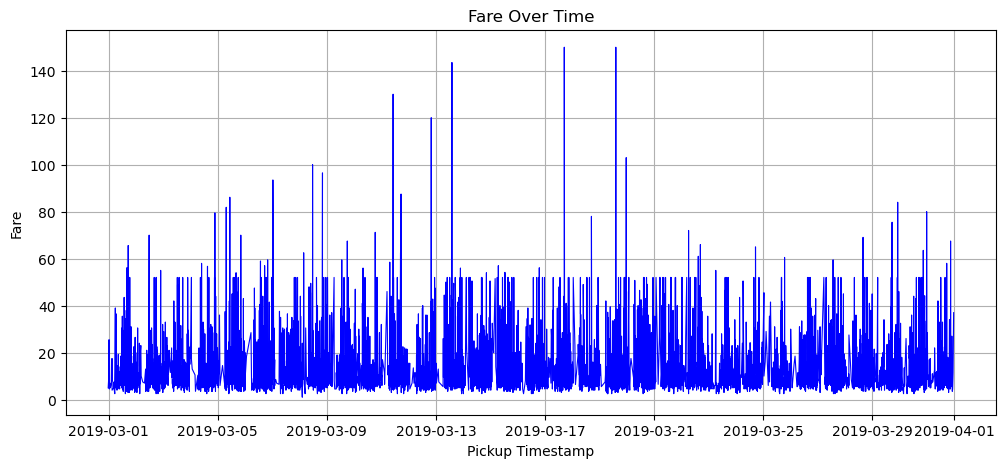

In [61]:
df['pickup'] = pd.to_datetime(df['pickup'])
df_sorted = df.sort_values('pickup')

plt.figure(figsize=(12, 5))
plt.plot(df_sorted['pickup'], df_sorted['fare'], color='blue', linewidth=0.8)
plt.title('Fare Over Time')
plt.xlabel('Pickup Timestamp')
plt.ylabel('Fare')
plt.grid(True)
plt.show()

# bar chart

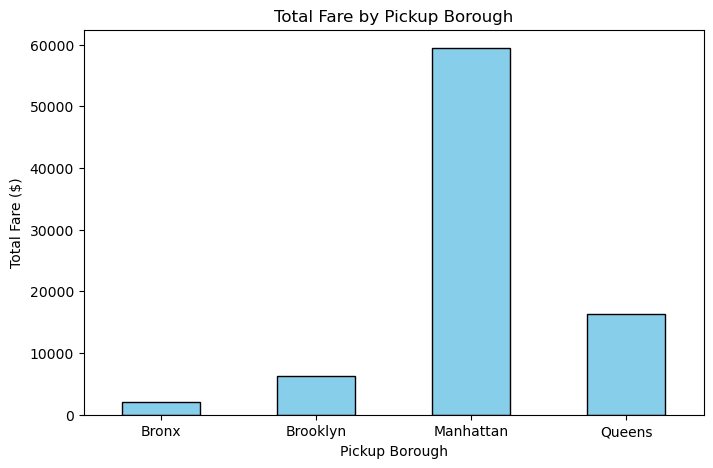

In [52]:
plt.figure(figsize=(8, 5))
borough_fare = df.groupby('pickup_borough')['fare'].sum()
borough_fare.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Fare by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare ($)')
plt.xticks(rotation=0)
plt.show()

#  Pie Chart  

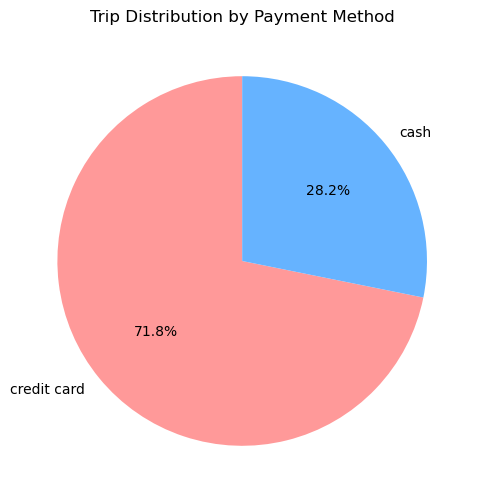

In [37]:
plt.figure(figsize=(6, 6))
payment_counts = df['payment'].value_counts()
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999', '#66b3ff'],
)
plt.title('Trip Distribution by Payment Method')
plt.show()

# Histogram  

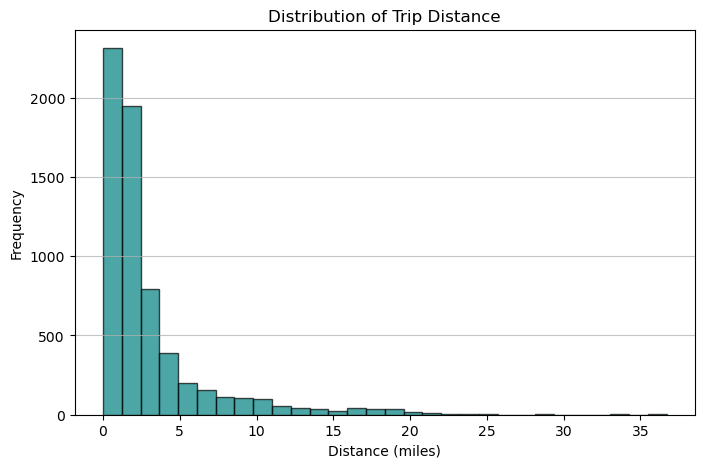

In [38]:
plt.figure(figsize=(8, 5))
plt.hist(
    df['distance'], bins=30, color='teal', edgecolor='black', alpha=0.7
)
plt.title('Distribution of Trip Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# box plot

<Figure size 800x500 with 0 Axes>

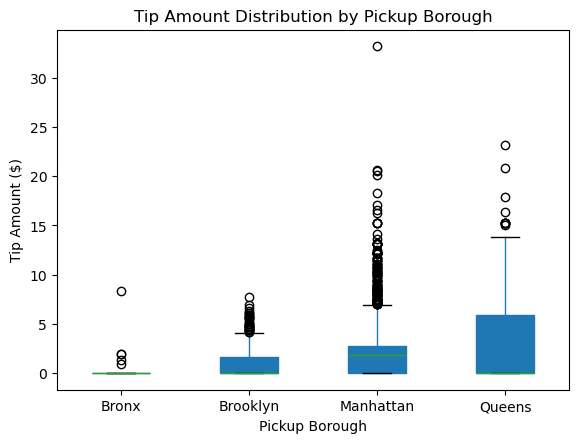

In [39]:
plt.figure(figsize=(8, 5))
df.boxplot(column='tip', by='pickup_borough', grid=False, patch_artist=True)
plt.title('Tip Amount Distribution by Pickup Borough')
plt.suptitle('')  # Removes automatic pandas subplot title
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount ($)')
plt.show()

 # Count Plot 

C:\Users\deepak k divakaran\AppData\Local\Temp\ipykernel_13904\1163708417.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pickup_borough', palette='viridis')


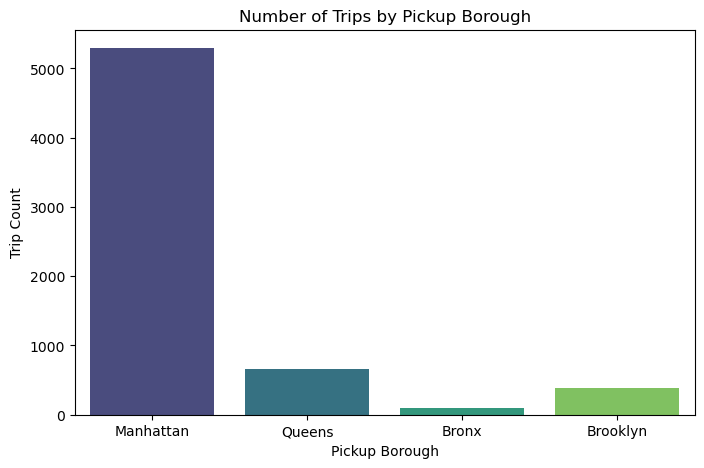

In [40]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='pickup_borough', palette='viridis')
plt.title('Number of Trips by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Trip Count')
plt.show()

# Scatter Plot  

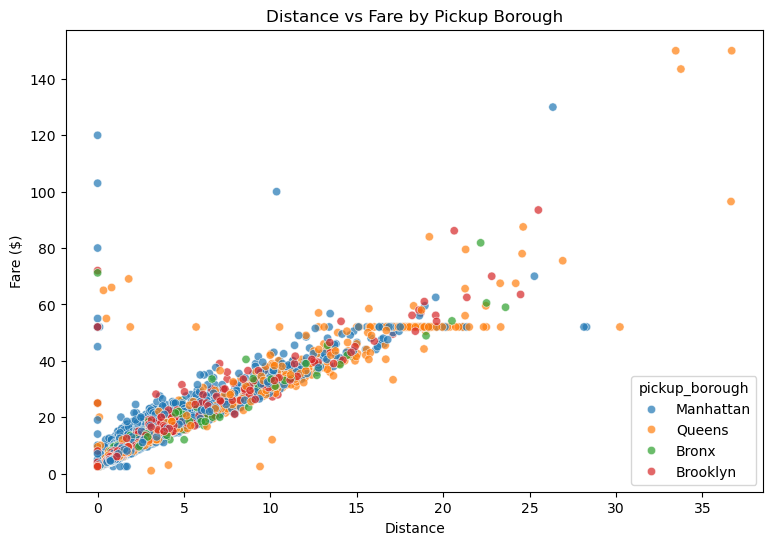

In [41]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x='distance', y='fare', hue='pickup_borough', alpha=0.7
)
plt.title('Distance vs Fare by Pickup Borough')
plt.xlabel('Distance')
plt.ylabel('Fare ($)')
plt.show()

# Heatmap  

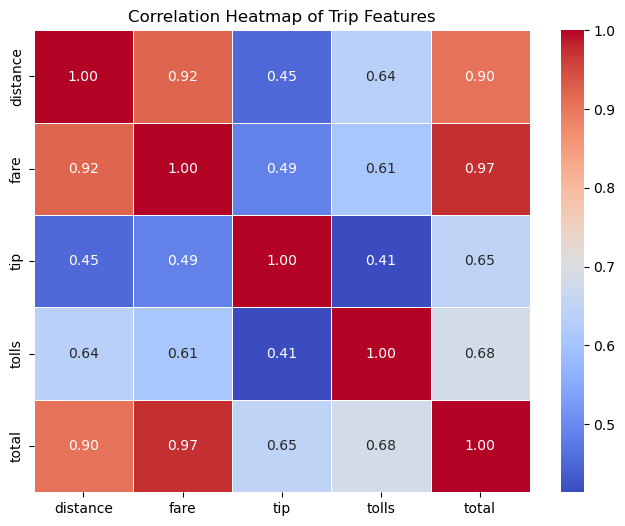

In [42]:
plt.figure(figsize=(8, 6))
corr_matrix = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Trip Features')
plt.show()

# Pair Plot

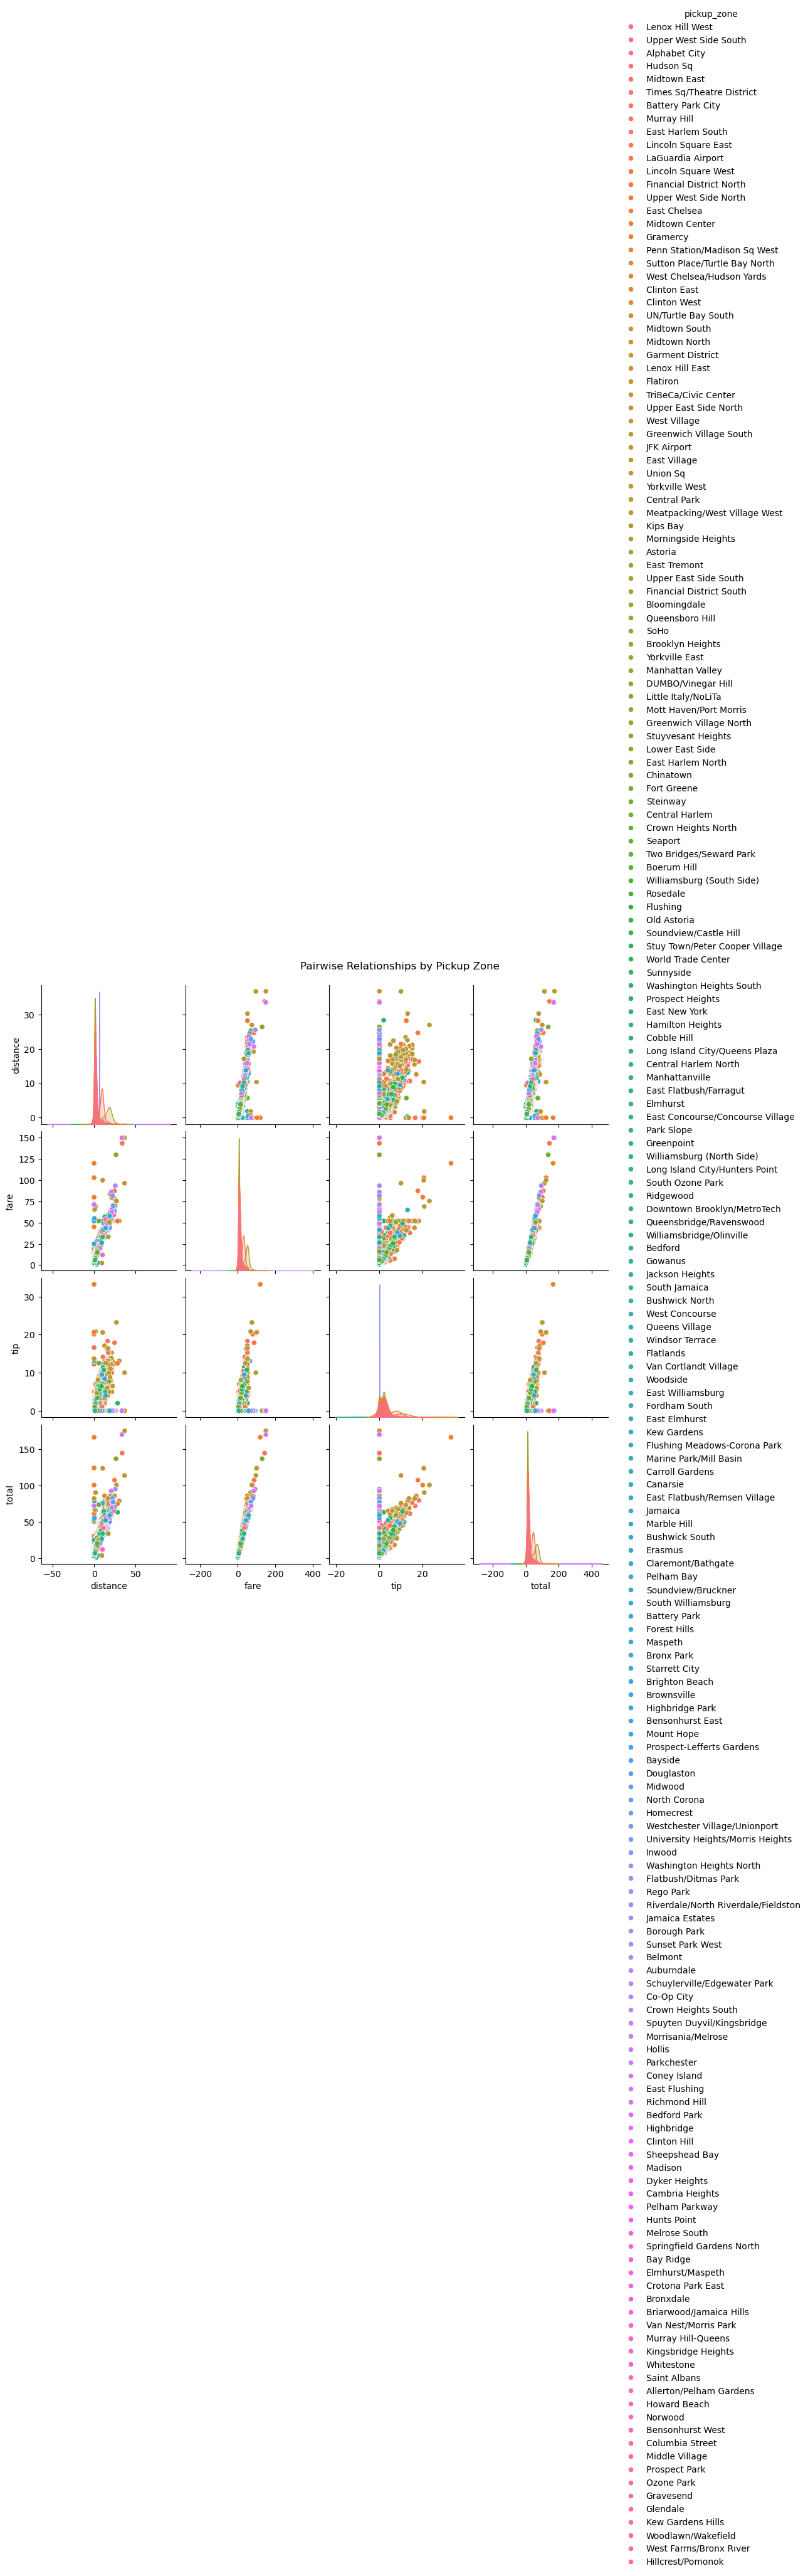

In [43]:
sns.pairplot(
    df[['distance', 'fare', 'tip', 'total', 'pickup_zone']],
    hue='pickup_zone',
)
plt.suptitle(
    'Pairwise Relationships by Pickup Zone', y=1.02
)  # Title adjustment
plt.show()

# Violin Plot

C:\Users\deepak k divakaran\AppData\Local\Temp\ipykernel_13904\3530799145.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


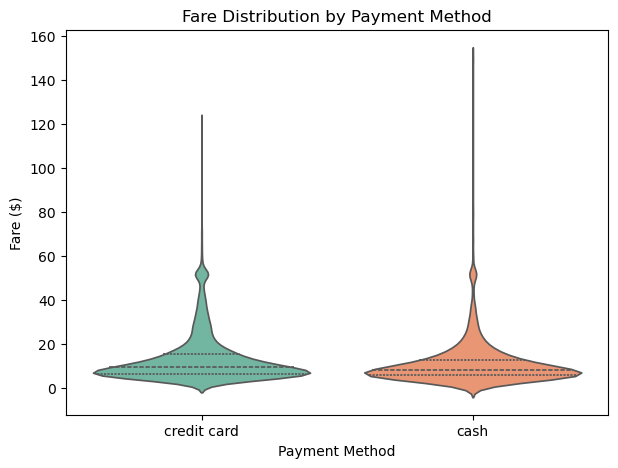

In [62]:
plt.figure(figsize=(7, 5))
sns.violinplot(
    data=df, x='payment', y='fare', palette='Set2', inner='quartile'
)
plt.title('Fare Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare ($)')
plt.show()